# 1. Pipeline

The pipeline is a sequence of data processing steps that are applied to the input data. Usually we have a training pipeline and an inference pipeline. The training pipeline is used to train the model, while the inference pipeline is used to make predictions on new data.

e.g.
strandardlize -> PCA -> classifier
```python
from sklearning.pipeline import make_pipeline
from sklearning.preprocessing import StandardScaler
from sklearning.decomposition import PCA
from sklearning.linear_model import LogisticRegression

pipe_lr = make_pipeline(
    StandardScaler(),
    PCA(n_components=2),
    LogisticRegression()
)

pipe_lr.fit(X_train, y_train)
y_pred = pipe_lr.predict(X_test)
print('Test Accuracy: %.3f' % pipe_lr.score(X_test, y_test))
```

# 2. Validation
Validation is the process of evaluating the performance of a model on a separate dataset that was not used during training. This is important to ensure that the model generalizes well to new data and does not overfit to the training data.

1. **Hold-out validation**: 
   + The dataset is split into two(three) parts: 
     + a training set
     + a test set
     + a validation set (optional, used for hyperparameter tuning)
   + Usually we use 70% of the data for training and 30% for testing, but this can vary depending on the size of the dataset and the specific problem.
2. **K-fold cross-validation**: 
   + The dataset is divided into k subsets (folds). The model is trained on $k-1$ folds and evaluated on the remaining fold. This process is repeated k times, with each fold serving as the test set once. The average performance across all folds is used as the final evaluation metric.
   + Choice of k:
     + Common choices for k are 5 or 10
     + For small datasets, a larger k (e.g., 10) may be preferred to maximize the training data in each fold.
     + For larger datasets, a smaller k (e.g., 5) may be sufficient and can reduce computational time.
3. **Leave One Out Cross Validation, (LOOCV)**:
   + This is a special case of k-fold cross-validation where k is equal to the number of samples in the dataset. Each sample is used as a test set once, and the model is trained on all other samples. This method can be computationally expensive for large datasets but provides an unbiased estimate of model performance.
4. **Stratified K-fold Cross Validation**:
   + This is a **variation** of k-fold cross-validation that ensures that each fold has a representative distribution of the target variable. This is particularly important for imbalanced datasets, where one class may be underrepresented. Stratified k-fold cross-validation helps to ensure that the model is evaluated on a more balanced set of data in each fold.

# 3. Learning and validation curves
## 3.1 Learning curves
Learning curves are a graphical representation of the model's performance on the training and validation sets as a function of the number of training samples. They can be used to diagnose whether a model is **overfitting** or **underfitting**.
e.g.
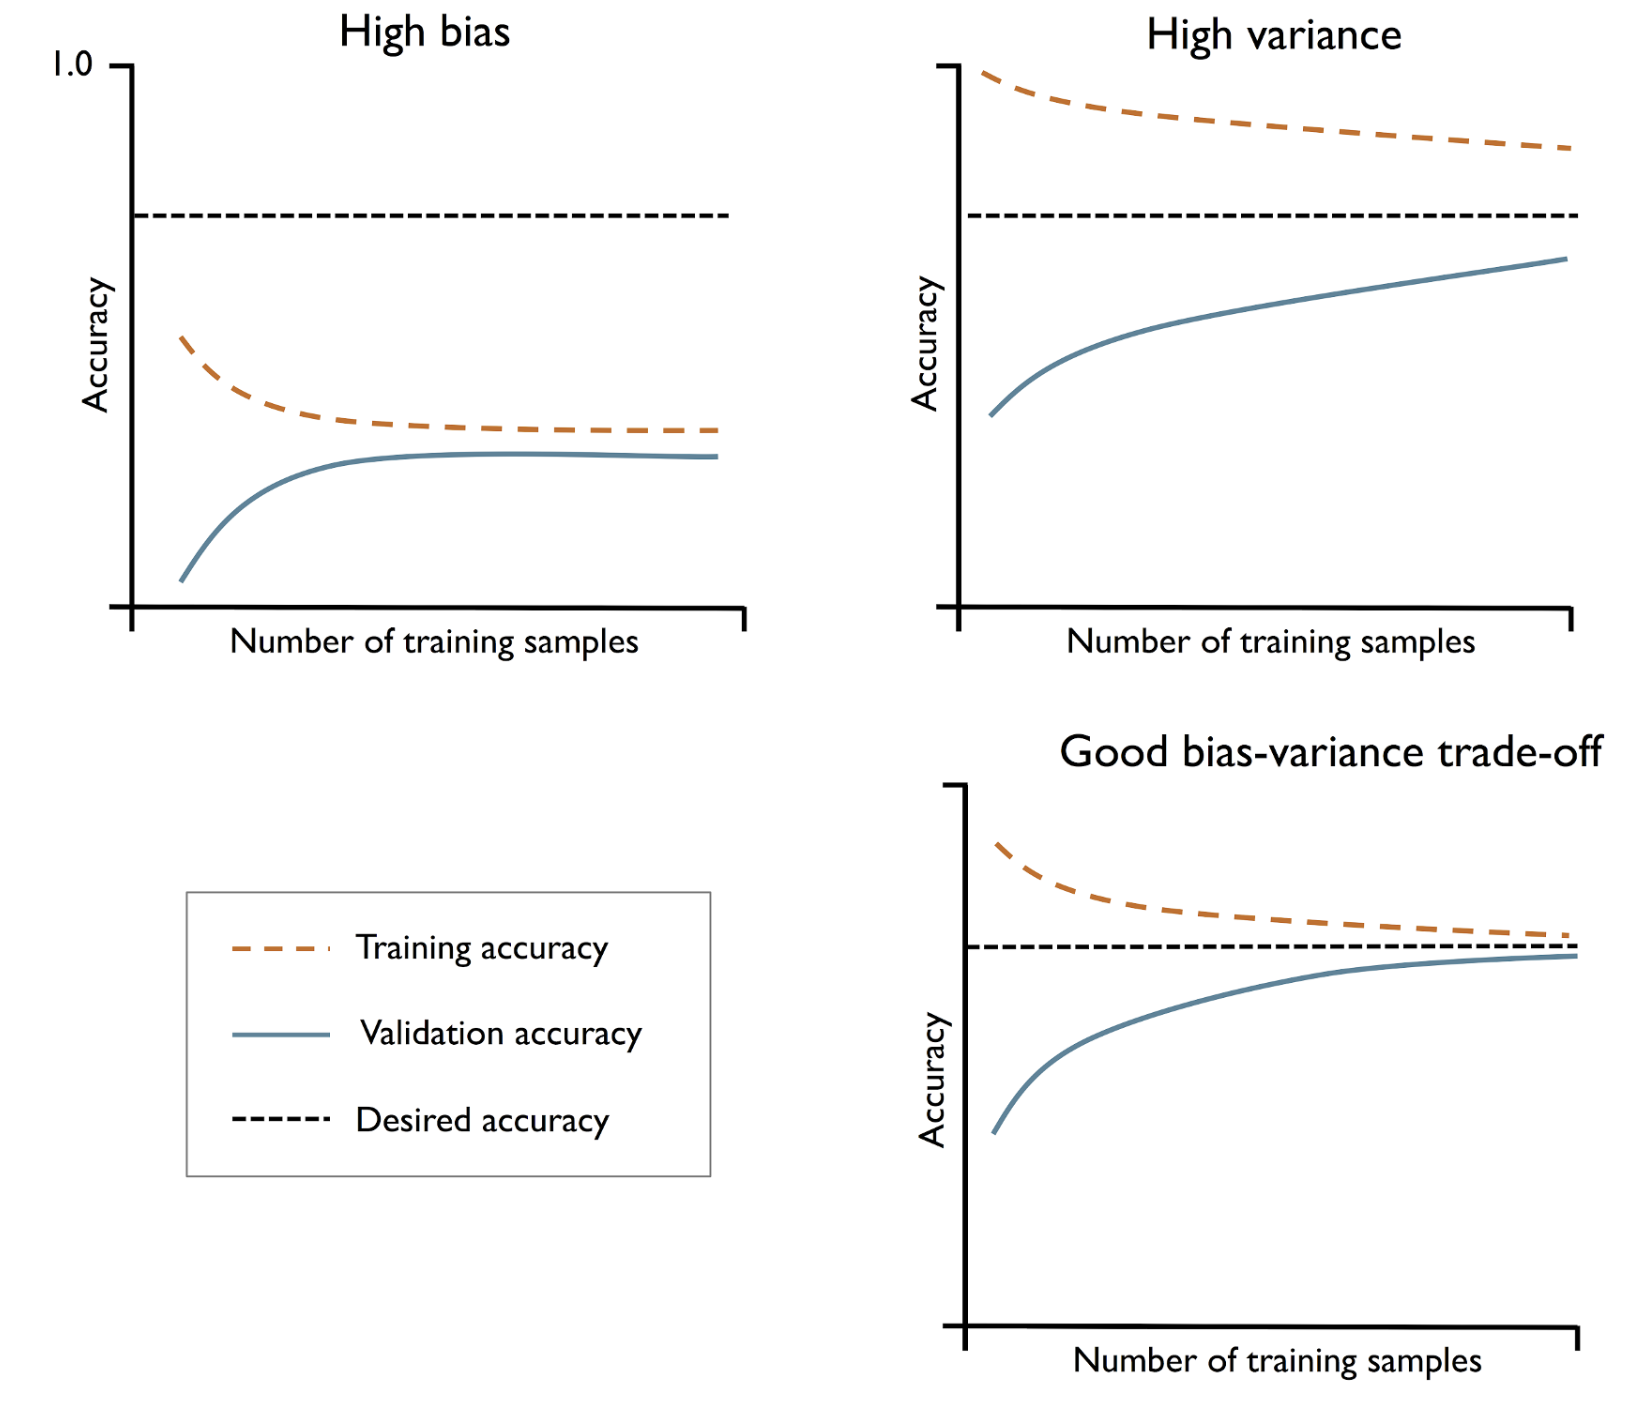


## 3.2 Validation curves
Validation curves are a graphical representation of the model's performance on the training and validation sets as a function of a hyperparameter. They can be used to diagnose whether a model is **overfitting** or **underfitting** with respect to a specific hyperparameter.

# 4. Hyperparameter Tuning
Hyperparameter search is the process of finding the best hyperparameters for a model. 

## 4.1 Grid Search
We brutely enumerate all possible combinations of hyperparameters and evaluate the model on each combination.
+ Pros:
  + Simple to implement
  + Can find the best hyperparameters if the search space is small
  + Can be easily parallelized
+ Cons:
  + Computationally expensive for large search spaces
  + May miss the best hyperparameters if the search space is not fine-grained enough

## 4.2 Random Search
We randomly sample hyperparameters from a specified distribution and evaluate the model on each combination.
+ Pros:
  + More efficient than grid search for large search spaces
  + Often can find good hyperparameters even with a limited number of evaluations
+ Cons:
  + May miss the best hyperparameters if the search space is not well-defined
  + Results can be variable due to randomness

## 4.3 Bayesian Optimization
Bayesian optimization is a more sophisticated method that builds a probabilistic model of the objective function and uses it to select the most promising hyperparameters to evaluate next.

### 4.3.1 Core idea:
We want to find the hyperparameters that minimize a loss function (e.g., validation error). The core idea of Bayesian optimization is to **struct a surrogate model** to approaximate the loss function based on the hyperparameters evaluated so far. 

**Sequential model-based optimization (SMBO)**:
$$
\begin{aligned}
\text{Next hyperparameters} 
&= \arg\max_{\text{hyperparameters}} \text{AcquisitionFunction}(\text{hyperparameters} | \text{surrogate model})\\
&= \arg\min_{\text{hyperparameters}} \mathbb{E}[\text{loss}(\text{hyperparameters}) | \text{data}]
\end{aligned}
$$

### 4.3.2 Surrogate model:
+ The surrogate model is a probabilistic model that approximates the true loss function. 
+ Common choices is **Gaussian Process**, which provides a mean and variance for the predicted loss at any given set of hyperparameters.
+ The surrogate model is updated after each evaluation of the true loss function(get a new observation $(x, f(x))$), allowing it to improve its predictions over time.

### 4.3.3 Acquisition function:
+ The acquisition function is used to determine which hyperparameters to evaluate next based on the surrogate model's predictions.
+ Common acquisition functions include:
  + **Expected Improvement (EI)**: Selects hyperparameters that are expected to improve upon the best observed loss so far.
  + **Upper Confidence Bound (UCB)**: Selects hyperparameters that have a high predicted mean loss or a high uncertainty (variance) in the surrogate model's predictions.
  + **Probability of Improvement (PI)**: Selects hyperparameters that have a high probability of improving upon the best observed loss so far.
+ The acquisition function balances exploration (trying hyperparameters with high uncertainty) and exploitation (trying hyperparameters with low predicted loss) to efficiently search the hyperparameter space.

## 4.4 Nested Cross-Validation
Note that when we optimize the hyperparameters, we should not use the test set to evaluate the model, as this can lead to overfitting on the test set. Instead, we can use **nested cross-validation**, which involves an inner loop for hyperparameter tuning and an outer loop for model evaluation. This allows us to get an unbiased estimate of the model's performance on unseen data while still optimizing the hyperparameters effectively.

+ **Outer loop**: 
  + Used to evaluate the performance of the model on unseen data.
  + Often implemented by **k-fold cross-validation**.
+ **Inner loop**: 
  + Used to optimize the hyperparameters of the model.
  + Can be implemented using grid search, random search, or Bayesian optimization on the training folds of the outer loop.
e.g.
```python
inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=inner_cv, scoring='accuracy')
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(grid_search, X, y, cv=outer_cv, scoring='accuracy')
```

# 5.Performance Evaluation Metrics

Except for accuracy, there are many other performance evaluation metrics that can be used to evaluate the performance of a model, especially for imbalanced datasets.

## 5.1 Confusion Matrix
> That's the fundamental concept of performance evaluation.

Confusion matrix is a table that is used to evaluate the performance of a classification model. It contains four values:
+ **True Positive (TP)**: The number of instances that are correctly predicted as positive.
+ **True Negative (TN)**: The number of instances that are correctly predicted as negative.
+ **False Positive (FP)**: The number of instances that are incorrectly predicted as positive.
+ **False Negative (FN)**: The number of instances that are incorrectly predicted as negative.

e.g.
```python
confmat = confusion_matrix(y_true = y_test, y_pred = y_pred)
```

By those defination, we can then calculate some important value of evaluation.

## 5.2 Error and Accuracy
+ **Error**: 
  + The proportion of incorrect predictions out of the total number of predictions.
  + $$ERR = \frac{FP + FN}{TP + TN + FP + FN} = \frac{False}{Total}$$
+ **Accuracy**: 
  + The proportion of correct predictions out of the total number of predictions.
  + $$ACC = \frac{TP + TN}{TP + TN + FP + FN} = \frac{True}{Total}$$
+ Advance accuracy
  + **True Positive Rate (TPR)**: 
    + The proportion of actual positive instances that are correctly predicted as positive.
    + $$TPR = \frac{TP}{TP + FN} = \frac{TP}{\text{True Classification}}$$
  + **True Negative Rate (TNR)**: 
    + The proportion of actual negative instances that are correctly predicted as negative.
    + $$TNR = \frac{TN}{TN + FP} = \frac{TN}{\text{True Classification}}$$
  + **False Positive Rate (FPR)**:
    + The proportion of actual negative instances that are incorrectly predicted as positive.
    + $$FPR = \frac{FP}{TN + FP} = \frac{FP}{\text{True Classification}}$$
  + **False Negative Rate (FNR)**: 
    + The proportion of actual positive instances that are incorrectly predicted as negative.
    + $$FNR = \frac{FN}{TP + FN} = \frac{FN}{\text{True Classification}}$$
+ **Precision**: 
  + The proportion of predicted positive instances that are actually positive.
  + $$PRE = \frac{TP}{TP + FP} = \frac{TP}{\text{Positive}}$$
+ **Recall**: 
  + The proportion of actual positive instances that are correctly predicted as positive (same as TPR).
  + $$REC = \frac{TP}{TP + FN} = \frac{TP}{\text{True Classification}}$$
+ **F1 Score**: 
  + The harmonic mean of precision and recall, providing a single metric that balances both.
  + $$F1 = 2 \cdot \frac{Precision \cdot Recall}{Precision + Recall}$$

## 5.3 ROC Curve and AUC
+ **Receiver Operating Characteristic (ROC) Curve**:
  + A graphical representation of the trade-off between the true positive rate (TPR) and false positive rate (FPR) at various threshold settings. The ROC curve plots TPR against FPR, and a model that performs better than random guessing will have a curve that bows towards the top-left corner of the plot.
  + Y-axis: TPR (Recall)
  + X-axis: FPR
  + A perfect model will have a point at (0, 1) on the ROC curve, indicating a TPR of 1 and an FPR of 0.
+ **Area Under the Curve (AUC)**:
  + A single scalar value that summarizes the overall performance of a model across all threshold settings.
  + The value of AUC is just the area under the ROC curve
    + i.e. $$\text{AUC} = \int_{0}^{1} \text{TPR}(FPR) d(FPR)$$
  + The more AUC approaches 1, the better the model's performance. An AUC less than 0.5 indicates a model that performs no better than random guessing, while an AUC of 1 indicates a perfect model.

## 5.4 For multiclass classification
For multiclass classification, we can use the following metrics:
+ **Macro-averaged metrics**:
  + Calculate the metric for each class independently and then take the average. This treats all classes equally, regardless of their frequency in the dataset.
  + e.g.$$PRE_{macro} = \frac{\sum_i PRE_i}{n}$$
+ **Micro-averaged metrics**:
  + Calculate the metric globally by counting the total true positives, false positives, and false negatives across all classes. This gives more weight to the performance on the more frequent classes.
    + e.g. $$PRE_{micro} = \frac{\sum_i TP_i}{\sum_i TP_i + \sum_i FP_i}$$
+ **Weighted-averaged metrics**:
  + Calculate the metric for each class independently and then take the average, weighted by the number of instances in each class. This accounts for class imbalance by giving more weight to the performance on the more frequent classes while still considering the performance on the less frequent classes.

> The default metric for multiclass classification in scikit-learn is usually the macro-averaged metric, but it can be specified using the `average` parameter in functions like `precision_score`, `recall_score`, and `f1_score`.
> e.g. 
```python
from sklearn.metrics import precision_score, recall_score, f1_score
precision_macro = precision_score(y_true, y_pred, average='macro')
recall_macro = recall_score(y_true, y_pred, average='macro')
f1_macro = f1_score(y_true, y_pred, average='macro')
```




# 6. Imbalanced Classification
Consider such case: we have a dataset with 1000 samples, where 990 samples belong to class 0 and only 10 samples belong to class 1. An model that always predicts class 0 will have an accuracy of 99%, which seems very good, but it is actually a poor model because it fails to identify any of the instances of class 1. Here are some common techniques to handle imbalanced classification problems:

## 6.1 Change the evaluation metric
Instead of using accuracy, we can use other metrics that are more informative for imbalanced datasets:
+ Recall (Sensitivity): 
  + If the cost of false negatives is high (e.g., in medical diagnosis)
  + Focuses on the ability of the model to **correctly identify** positive instances, which is crucial when the minority class is of greater interest.
+ Precision: 
  + If the cost of false positives is high (e.g., in spam detection)
  + Focuses on the accuracy of the **positive predictions**, which is important when false positives are costly.
+ F1 Score: 
  + Provides a balance between precision and recall, giving a single metric that considers both false positives and false negatives.
+ Area Under the ROC Curve (AUC): 
  + Evaluates the model's ability to distinguish between classes across all threshold settings, which can be more informative than accuracy in imbalanced scenarios.
  
## 6.2 Model Fitting
We consider **Class Weight**  to give more importance to the minority class during training. This can be done by assigning a higher weight to the minority class in the loss function, which encourages the model to pay more attention to it.  
```python
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(class_weight='balanced')
```

## 6.3 Resampling Techniques

### 6.3.1 Upsampling
We can increase the number of samples in the minority class by duplicating existing samples or generating new synthetic samples (e.g., using SMOTE). This can help the model learn more about the minority class and improve its performance on that class.
```python
from sklearn.utils import resample
# Upsample minority class
X_minority_upsampled, y_minority_upsampled = resample(X_minority, y_minority, replace=True, n_samples=len(X_majority), random_state=42)
```

### 6.3.2 Downsampling
We can decrease the number of samples in the majority class by randomly removing samples. This can help the model focus more on the minority class, but it may also lead to loss of information from the majority class.
```python
from sklearn.utils import resample
# Downsample majority class
X_majority_downsampled, y_majority_downsampled = resample(X_majority, y_majority, replace=False, n_samples=len(X_minority), random_state=42)
```